In [1]:
# import pandas as pd
# from sentence_transformers import SentenceTransformer
# from sklearn.manifold import TSNE
# import matplotlib.pyplot as plt
# import numpy as np

# # 1. Load your data
# df = pd.read_csv("/kaggle/input/hp-all/Final_results.csv")

# # 2. Drop unwanted columns
# ignore_cols = ['image_path', 'styled', 'caption']  # columns to ignore
# model_cols = [c for c in df.columns if c not in ignore_cols]  # keep only model output columns

# # 3. Initialize sentence embedding model
# embedder = SentenceTransformer('all-MiniLM-L6-v2')  # or 'BAAI/bge-base-en-v1.5'

# # 4. Melt dataframe (keep GT separately)
# melted = df.melt(id_vars=['caption'], 
#                  value_vars=model_cols,
#                  var_name='model', 
#                  value_name='generated_caption')

# # 5. Encode all captions (models + ground truth)
# all_texts = melted['generated_caption'].tolist() + df['caption'].tolist()
# embeddings = embedder.encode(all_texts, show_progress_bar=True)

# # 6. Create labels
# labels = melted['model'].tolist() + ['ground_truth'] * len(df)

# # 7. Apply t-SNE
# tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
# reduced = tsne.fit_transform(embeddings)

# # 8. Plot
# plt.figure(figsize=(10,8))
# unique_labels = list(set(labels))
# colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

# for i, label in enumerate(unique_labels):
#     mask = np.array(labels) == label
#     plt.scatter(reduced[mask, 0], reduced[mask, 1], alpha=0.6, label=label, color=colors[i])

# plt.legend()
# plt.title("t-SNE Projection of Caption Embeddings")
# plt.xlabel("Dimension 1")
# plt.ylabel("Dimension 2")

# # 9. Save figure
# plt.savefig("caption_embeddings_tsne.png", dpi=300, bbox_inches='tight')

# # 10. Show figure
# plt.show()

2025-10-05 18:40:21.286858: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759689621.465034      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759689621.517266      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/114 [00:00<?, ?it/s]

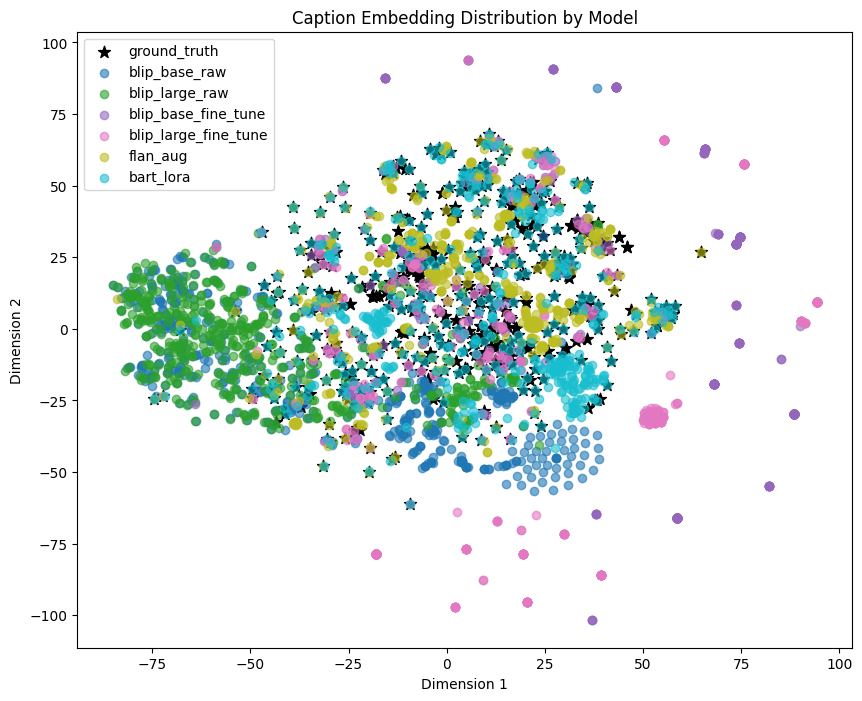

In [2]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# 1. Load your data
df = pd.read_csv("/kaggle/input/hp-all/Final_results.csv")

# 2. Drop unwanted columns
ignore_cols = ['image_path', 'styled']  # columns to ignore
model_cols = [c for c in df.columns if c not in ignore_cols + ['caption']]  # model output columns

# 3. Initialize sentence embedding model
embedder = SentenceTransformer('all-MiniLM-L6-v2')  # or 'BAAI/bge-base-en-v1.5'

# 4. Melt dataframe (keep ground truth separately)
melted = df.melt(id_vars=['caption'], 
                 value_vars=model_cols,
                 var_name='model', 
                 value_name='generated_caption')

# 5. Encode all captions (models + ground truth)
all_texts = melted['generated_caption'].tolist() + df['caption'].tolist()
embeddings = embedder.encode(all_texts, show_progress_bar=True)

# 6. Create labels
labels = melted['model'].tolist() + ['ground_truth'] * len(df)

# 7. Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
reduced = tsne.fit_transform(embeddings)

# 8. Define desired order for legend
desired_order = ['ground_truth', 'blip_base_raw', 'blip_large_raw', 
                 'blip_base_fine_tune', 'blip_large_fine_tune', 
                 'flan_aug', 'bart_lora']

# 9. Assign colors for models (ground truth will be black star)
colors = plt.cm.tab10(np.linspace(0, 1, len(desired_order)-1))  # one less because ground truth is black

plt.figure(figsize=(10,8))

for i, label in enumerate(desired_order):
    mask = np.array(labels) == label
    if label == 'ground_truth':
        plt.scatter(reduced[mask,0], reduced[mask,1], 
                    marker='*', color='black', s=80, label=label)  # black star
    else:
        plt.scatter(reduced[mask,0], reduced[mask,1], 
                    alpha=0.6, label=label, color=colors[i-1])  # colored circles

plt.legend()
plt.title("Caption Embedding Distribution by Model")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

# 10. Save figure
plt.savefig("caption_embeddings_tsne_ordered.png", dpi=300, bbox_inches='tight')

# 11. Show figure
plt.show()
